In [1]:
# Librerías necesarias
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
)


In [ ]:
# Ruta local de la carpeta Prepared.
BASE_DIR = Path(r"C:\Users\oieru\OneDrive\Escritorio\MASTER\00-TFM\00-TFM_FINAL\DataBase\Limpio2\Prepared")

if not BASE_DIR.exists():
    raise FileNotFoundError(f"No se ha encontrado la carpeta Prepared en: {BASE_DIR}")

print("Carpeta de trabajo:", BASE_DIR)


Carpeta de trabajo: C:\Users\oieru\OneDrive\Escritorio\MASTER\00-TFM\00-TFM_FINAL\DataBase\Limpio2\Prepared


In [ ]:
def load_predictions(relative_path, model_name, group, pred_col="pred", prob_col=None, fold_map_path=None):
    "Carga un archivo de predicciones y normaliza los nombres de columnas."
    path = BASE_DIR / relative_path
    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    df = pd.read_csv(path).copy()
    df = df.rename(columns={pred_col: "y_pred"})

    
    if "outer_fold" not in df.columns and fold_map_path is not None:
        fold_path = BASE_DIR / fold_map_path
        fold_df = pd.read_csv(fold_path)[["subject_id", "outer_fold"]].drop_duplicates()
        df = df.merge(fold_df, on="subject_id", how="left")

    # En algunos modelos la probabilidad se llama distinto.
    if prob_col is not None and prob_col in df.columns:
        df = df.rename(columns={prob_col: "y_score"})
    elif "prob_1" in df.columns:
        df = df.rename(columns={"prob_1": "y_score"})
    elif "y_prob" in df.columns:
        df = df.rename(columns={"y_prob": "y_score"})
    elif "score_1" in df.columns:
        df = df.rename(columns={"score_1": "y_score"})

    needed = ["subject_id", "label", "outer_fold", "y_pred"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en {relative_path}: {missing}")

    if df["outer_fold"].isna().any():
        raise ValueError(f"Hay sujetos sin outer_fold en {relative_path}")

    df = df[needed + (["y_score"] if "y_score" in df.columns else [])].copy()
    df["model"] = model_name
    df["group"] = group
    return df


def fold_metrics(df):
    "Calcula métricas subject-level test en cada fold externo."
    rows = []
    for fold, d in df.groupby("outer_fold"):
        y_true = d["label"].astype(int)
        y_pred = d["y_pred"].astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        rows.append({
            "outer_fold": fold,
            "N sujetos": len(d),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "MCC": matthews_corrcoef(y_true, y_pred),
            "Accuracy": accuracy_score(y_true, y_pred),
            "TPR": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "TNR": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        })
    return pd.DataFrame(rows)


def summarize_model(df):
    "Devuelve media y desviación estándar de las métricas por fold."
    fm = fold_metrics(df)
    out = {
        "Modelo": df["model"].iloc[0],
        "Grupo": df["group"].iloc[0],
        "N sujetos": df["subject_id"].nunique(),
    }
    for m in ["F1", "MCC", "Accuracy", "TPR", "TNR"]:
        out[f"{m} media"] = fm[m].mean()
        out[f"{m} std"] = fm[m].std(ddof=1)
    return out


def make_summary(predictions):
    "Crea tabla resumen para una lista de dataframes de predicciones."
    return pd.DataFrame([summarize_model(df) for df in predictions])


def format_mean_std(summary):
    "Crea una tabla con formato media +/- std."
    table = summary[["Modelo", "Grupo", "N sujetos"]].copy()
    for m in ["F1", "MCC", "Accuracy", "TPR", "TNR"]:
        table[m] = summary.apply(lambda r: f"{r[f'{m} media']:.3f} ± {r[f'{m} std']:.3f}", axis=1)
    return table


def plot_confusion(df, title=None):
    "Dibuja la matriz de confusión agregada sobre todos los sujetos de test."
    y_true = df["label"].astype(int)
    y_pred = df["y_pred"].astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm)
    ax.set_title(title or df["model"].iloc[0])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Etiqueta real")
    ax.set_xticks([0, 1], ["Control", "Síntomas"])
    ax.set_yticks([0, 1], ["Control", "Síntomas"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_f1_mcc_overlay(summary, title=None):
    """Dibuja un gráfico de barras superpuestas: F1 en azul y MCC en rojo."""
    d = summary.sort_values("F1 media", ascending=False).copy()

    modelos = d["Modelo"]
    f1 = d["F1 media"]
    mcc = d["MCC media"]
    y = np.arange(len(d))

    fig, ax = plt.subplots(figsize=(10, max(4, 0.42 * len(d))))

    
    ax.barh(y, f1, height=0.65, color="blue", alpha=0.65, label="F1")
    ax.barh(y, mcc, height=0.35, color="red", alpha=0.80, label="MCC")

    ax.set_yticks(y)
    ax.set_yticklabels(modelos)
    ax.invert_yaxis()
    ax.set_xlabel("Valor medio")
    ax.set_title(title or "Comparación F1 y MCC")
    ax.set_xlim(min(0, mcc.min() - 0.05), max(1.0, f1.max() + 0.08))
    ax.axvline(0, linewidth=0.8)
    ax.legend(loc="lower right")

    
    for i, (v_f1, v_mcc) in enumerate(zip(f1, mcc)):
        ax.text(v_f1 + 0.01, i - 0.15, f"F1={v_f1:.3f}", va="center", fontsize=8)
        ax.text(v_mcc + 0.01, i + 0.15, f"MCC={v_mcc:.3f}", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


In [ ]:
models = [
    
    # 3.1 Modelos de referencia
    ("Text", "3.1 Referencia", "02_results_text_xgboost_paper/subject_predictions_global.csv", "pred", "prob_1", None),
    ("Speech", "3.1 Referencia", "02_results_speech_xgboost_paper/subject_predictions_global.csv", "pred", "prob_1", None),
    ("Text+Speech", "3.1 Referencia", "03_results_text_speech_xgboost_paper/text_speech_subject_predictions_global.csv", "y_pred", "y_prob", "03_results_text_speech_xgboost_paper/text_speech_conversation_predictions.csv"),
    ("EEG Conversation", "3.1 Referencia", "02_results_eeg_conversation_paper_folds_unimodal/eeg_subject_predictions.csv", "y_pred", "y_prob", None),
    ("EEG Emotion-wise", "3.1 Referencia", "02_results_eeg_narrative_paper_folds_unimodal/eeg_subject_predictions.csv", "y_pred", "y_prob", None),

    # 3.2 Early fusion
    ("Early fusion Conversation XGBoost", "3.2 Early fusion", "05_results_text_speech_eeg_conversation_level/subject_predictions_global.csv", "pred", "prob_1", None),
    ("Early fusion Emotion-wise XGBoost", "3.2 Early fusion", "05_results_text_speech_eeg_emotion_wise/subject_predictions_global.csv", "pred", "prob_1", None),
    ("Early fusion Conversation SVM", "3.2 Early fusion", "05_results_text_speech_eeg_conversation_level_svm/subject_predictions_global.csv", "pred", "score_1", None),
    ("Early fusion Emotion-wise SVM", "3.2 Early fusion", "05_results_text_speech_eeg_emotion_wise_svm/subject_predictions_global.csv", "pred", "score_1", None),

    # 3.3 Reducción de dimensionalidad
    ("Early fusion PCA10 Conversation", "3.3 Reducción", "07_results_text_speech_eeg_conversation_level_PCA10/subject_predictions_global.csv", "pred", "prob_1", None),
    ("Early fusion PCA10 Emotion-wise", "3.3 Reducción", "07_results_text_speech_eeg_emotion_wise_PCA10/subject_predictions_global.csv", "pred", "prob_1", None),
    ("Early fusion PLS10 Conversation", "3.3 Reducción", "07_results_text_speech_eeg_conversation_PLS10/subject_predictions_global.csv", "pred", "prob_1", None),
    ("Early fusion PLS10 Emotion-wise", "3.3 Reducción", "07_results_text_speech_eeg_emotion_wise_PLS10/subject_predictions_aggregated.csv", "pred", "prob_1", None),

    # 3.4 Late fusion
    ("Late fusion", "3.4 Late fusion", "08_results_late_fusion_text_speech_eeg_narrative/late_fusion_subject_predictions.csv", "pred_fusion", "prob_fusion", None),
]

predictions = []
for name, group, path, pred_col, prob_col, fold_map_path in models:
    predictions.append(load_predictions(path, name, group, pred_col=pred_col, prob_col=prob_col, fold_map_path=fold_map_path))

all_summary = make_summary(predictions)
all_summary_formatted = format_mean_std(all_summary)

all_summary_formatted


,Modelo,Grupo,N sujetos,F1,MCC,Accuracy,TPR,TNR
0,Text,3.1 Referencia,101,0.358 ± 0.141,0.190 ± 0.212,0.623 ± 0.069,0.258 ± 0.116,0.882 ± 0.094
1,Speech,3.1 Referencia,101,0.582 ± 0.104,0.357 ± 0.156,0.693 ± 0.075,0.525 ± 0.142,0.811 ± 0.104
2,Text+Speech,3.1 Referencia,101,0.630 ± 0.056,0.428 ± 0.083,0.723 ± 0.044,0.575 ± 0.119,0.829 ± 0.089
3,EEG Conversation,3.1 Referencia,94,0.565 ± 0.231,0.359 ± 0.285,0.680 ± 0.145,0.544 ± 0.250,0.773 ± 0.223
4,EEG Emotion-wise,3.1 Referencia,94,0.680 ± 0.186,0.524 ± 0.213,0.754 ± 0.113,0.676 ± 0.251,0.811 ± 0.191
5,Early fusion Conversation XGBoost,3.2 Early fusion,94,0.503 ± 0.135,0.269 ± 0.193,0.649 ± 0.099,0.448 ± 0.180,0.797 ± 0.129
6,Early fusion Emotion-wise XGBoost,3.2 Early fusion,94,0.583 ± 0.107,0.381 ± 0.189,0.701 ± 0.085,0.508 ± 0.115,0.835 ± 0.121
7,Early fusion Conversation SVM,3.2 Early fusion,94,0.668 ± 0.164,0.442 ± 0.258,0.731 ± 0.122,0.663 ± 0.187,0.778 ± 0.090
8,Early fusion Emotion-wise SVM,3.2 Early fusion,94,0.493 ± 0.228,0.237 ± 0.270,0.646 ± 0.117,0.458 ± 0.251,0.778 ± 0.099
9,Early fusion PCA10 Conversation,3.3 Reducción,94,0.538 ± 0.161,0.307 ± 0.251,0.670 ± 0.122,0.471 ± 0.179,0.814 ± 0.100


In [5]:
summary_31 = all_summary[all_summary["Grupo"] == "3.1 Referencia"].sort_values("F1 media", ascending=False)
format_mean_std(summary_31)


,Modelo,Grupo,N sujetos,F1,MCC,Accuracy,TPR,TNR
4,EEG Emotion-wise,3.1 Referencia,94,0.680 ± 0.186,0.524 ± 0.213,0.754 ± 0.113,0.676 ± 0.251,0.811 ± 0.191
2,Text+Speech,3.1 Referencia,101,0.630 ± 0.056,0.428 ± 0.083,0.723 ± 0.044,0.575 ± 0.119,0.829 ± 0.089
1,Speech,3.1 Referencia,101,0.582 ± 0.104,0.357 ± 0.156,0.693 ± 0.075,0.525 ± 0.142,0.811 ± 0.104
3,EEG Conversation,3.1 Referencia,94,0.565 ± 0.231,0.359 ± 0.285,0.680 ± 0.145,0.544 ± 0.250,0.773 ± 0.223
0,Text,3.1 Referencia,101,0.358 ± 0.141,0.190 ± 0.212,0.623 ± 0.069,0.258 ± 0.116,0.882 ± 0.094


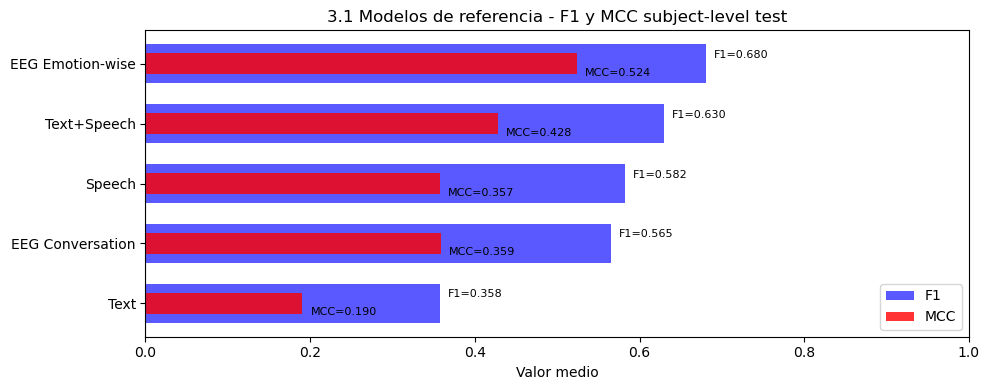

In [6]:
plot_f1_mcc_overlay(summary_31, title="3.1 Modelos de referencia - F1 y MCC subject-level test")

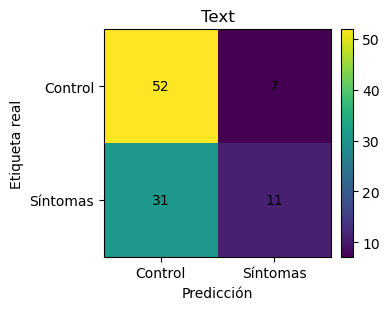

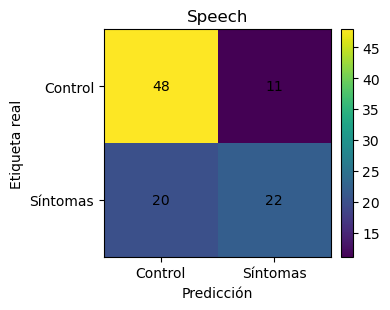

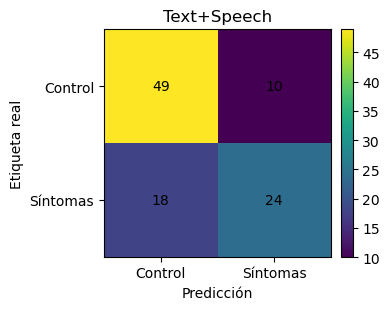

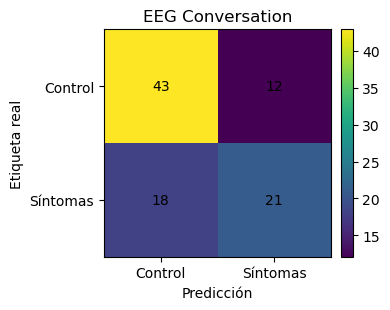

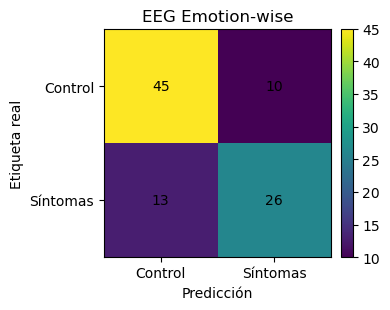

In [7]:
# Matrices de confusión de los modelos de referencia
for df in predictions:
    if df["group"].iloc[0] == "3.1 Referencia":
        plot_confusion(df, df["model"].iloc[0])


 early fusion




In [8]:
summary_32 = all_summary[all_summary["Grupo"] == "3.2 Early fusion"].sort_values("F1 media", ascending=False)
format_mean_std(summary_32)


,Modelo,Grupo,N sujetos,F1,MCC,Accuracy,TPR,TNR
7,Early fusion Conversation SVM,3.2 Early fusion,94,0.668 ± 0.164,0.442 ± 0.258,0.731 ± 0.122,0.663 ± 0.187,0.778 ± 0.090
6,Early fusion Emotion-wise XGBoost,3.2 Early fusion,94,0.583 ± 0.107,0.381 ± 0.189,0.701 ± 0.085,0.508 ± 0.115,0.835 ± 0.121
5,Early fusion Conversation XGBoost,3.2 Early fusion,94,0.503 ± 0.135,0.269 ± 0.193,0.649 ± 0.099,0.448 ± 0.180,0.797 ± 0.129
8,Early fusion Emotion-wise SVM,3.2 Early fusion,94,0.493 ± 0.228,0.237 ± 0.270,0.646 ± 0.117,0.458 ± 0.251,0.778 ± 0.099


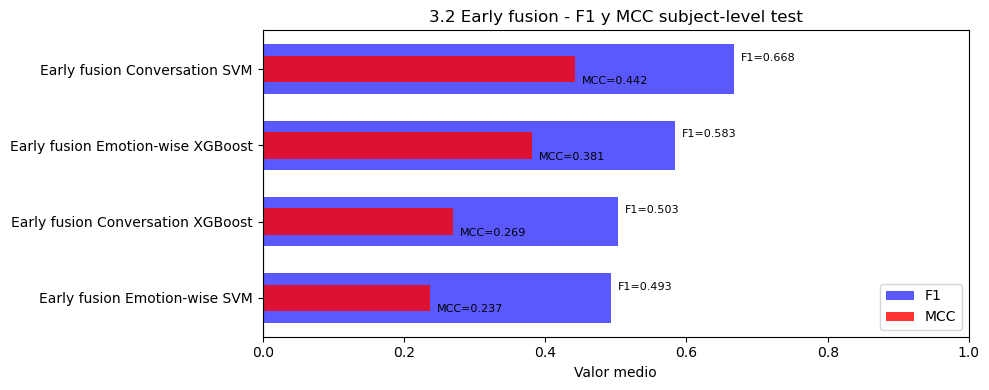

In [9]:
plot_f1_mcc_overlay(summary_32, title="3.2 Early fusion - F1 y MCC subject-level test")

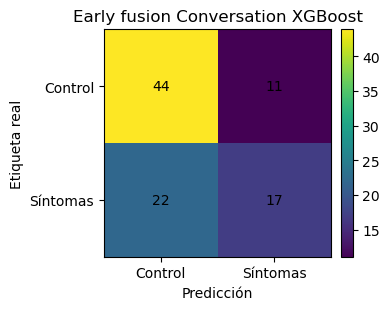

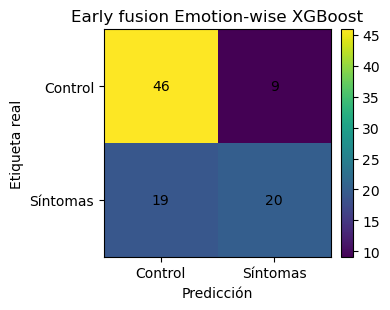

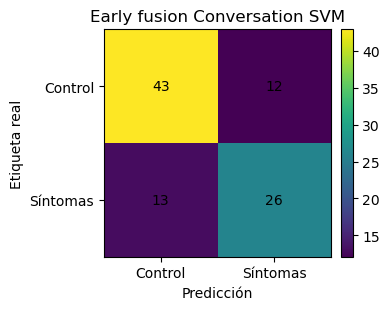

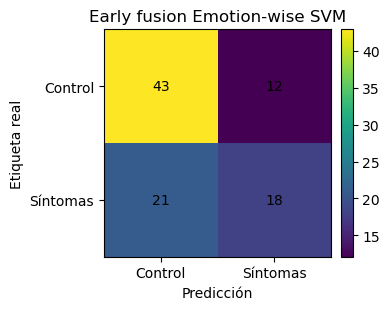

In [10]:
# Matrices de confusión de los modelos early fusion
for df in predictions:
    if df["group"].iloc[0] == "3.2 Early fusion":
        plot_confusion(df, df["model"].iloc[0])


modelos con reducción de dimensionalidad


In [11]:
summary_33 = all_summary[all_summary["Grupo"] == "3.3 Reducción"].sort_values("F1 media", ascending=False)
format_mean_std(summary_33)


,Modelo,Grupo,N sujetos,F1,MCC,Accuracy,TPR,TNR
10,Early fusion PCA10 Emotion-wise,3.3 Reducción,94,0.557 ± 0.210,0.406 ± 0.169,0.711 ± 0.085,0.490 ± 0.229,0.869 ± 0.114
9,Early fusion PCA10 Conversation,3.3 Reducción,94,0.538 ± 0.161,0.307 ± 0.251,0.670 ± 0.122,0.471 ± 0.179,0.814 ± 0.100
11,Early fusion PLS10 Conversation,3.3 Reducción,94,0.396 ± 0.178,0.133 ± 0.217,0.596 ± 0.092,0.344 ± 0.189,0.784 ± 0.092
12,Early fusion PLS10 Emotion-wise,3.3 Reducción,94,0.313 ± 0.199,0.119 ± 0.299,0.585 ± 0.101,0.259 ± 0.204,0.824 ± 0.207


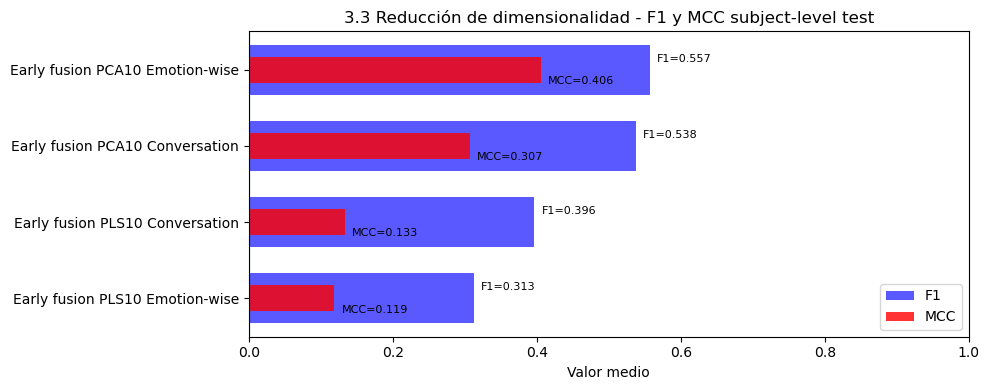

In [12]:
plot_f1_mcc_overlay(summary_33, title="3.3 Reducción de dimensionalidad - F1 y MCC subject-level test")

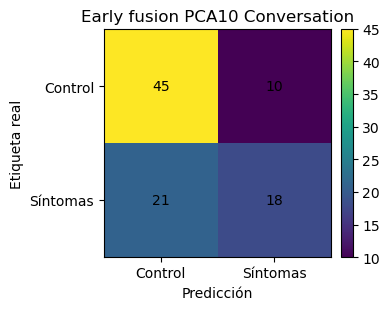

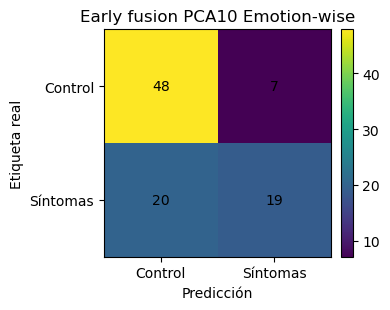

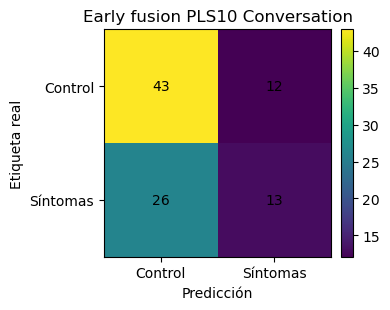

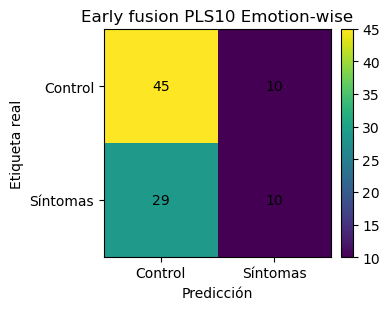

In [13]:
# Matrices de confusión de los modelos con reducción de dimensionalidad
for df in predictions:
    if df["group"].iloc[0] == "3.3 Reducción":
        plot_confusion(df, df["model"].iloc[0])


late fusion




In [14]:
summary_34 = all_summary[all_summary["Grupo"] == "3.4 Late fusion"].sort_values("F1 media", ascending=False)
format_mean_std(summary_34)


,Modelo,Grupo,N sujetos,F1,MCC,Accuracy,TPR,TNR
13,Late fusion,3.4 Late fusion,94,0.717 ± 0.108,0.576 ± 0.213,0.788 ± 0.105,0.622 ± 0.095,0.904 ± 0.138


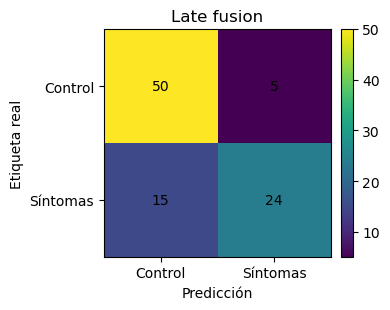

In [15]:
late_df = [df for df in predictions if df["model"].iloc[0] == "Late fusion"][0]
plot_confusion(late_df, "Late fusion")


In [16]:
# Métricas fold a fold del modelo late fusion
fold_metrics(late_df)


,outer_fold,N sujetos,F1,MCC,Accuracy,TPR,TNR
0,1,20,0.625000,0.389819,0.700000,0.555556,0.818182
1,2,18,0.625000,0.325000,0.666667,0.625000,0.700000
2,3,18,0.833333,0.777429,0.888889,0.714286,1.000000
3,4,19,0.833333,0.782461,0.894737,0.714286,1.000000
4,5,19,0.666667,0.605530,0.789474,0.500000,1.000000


Comparación global de modelos




In [17]:
summary_35 = all_summary.sort_values("F1 media", ascending=False).reset_index(drop=True)
format_mean_std(summary_35)


,Modelo,Grupo,N sujetos,F1,MCC,Accuracy,TPR,TNR
0,Late fusion,3.4 Late fusion,94,0.717 ± 0.108,0.576 ± 0.213,0.788 ± 0.105,0.622 ± 0.095,0.904 ± 0.138
1,EEG Emotion-wise,3.1 Referencia,94,0.680 ± 0.186,0.524 ± 0.213,0.754 ± 0.113,0.676 ± 0.251,0.811 ± 0.191
2,Early fusion Conversation SVM,3.2 Early fusion,94,0.668 ± 0.164,0.442 ± 0.258,0.731 ± 0.122,0.663 ± 0.187,0.778 ± 0.090
3,Text+Speech,3.1 Referencia,101,0.630 ± 0.056,0.428 ± 0.083,0.723 ± 0.044,0.575 ± 0.119,0.829 ± 0.089
4,Early fusion Emotion-wise XGBoost,3.2 Early fusion,94,0.583 ± 0.107,0.381 ± 0.189,0.701 ± 0.085,0.508 ± 0.115,0.835 ± 0.121
5,Speech,3.1 Referencia,101,0.582 ± 0.104,0.357 ± 0.156,0.693 ± 0.075,0.525 ± 0.142,0.811 ± 0.104
6,EEG Conversation,3.1 Referencia,94,0.565 ± 0.231,0.359 ± 0.285,0.680 ± 0.145,0.544 ± 0.250,0.773 ± 0.223
7,Early fusion PCA10 Emotion-wise,3.3 Reducción,94,0.557 ± 0.210,0.406 ± 0.169,0.711 ± 0.085,0.490 ± 0.229,0.869 ± 0.114
8,Early fusion PCA10 Conversation,3.3 Reducción,94,0.538 ± 0.161,0.307 ± 0.251,0.670 ± 0.122,0.471 ± 0.179,0.814 ± 0.100
9,Early fusion Conversation XGBoost,3.2 Early fusion,94,0.503 ± 0.135,0.269 ± 0.193,0.649 ± 0.099,0.448 ± 0.180,0.797 ± 0.129


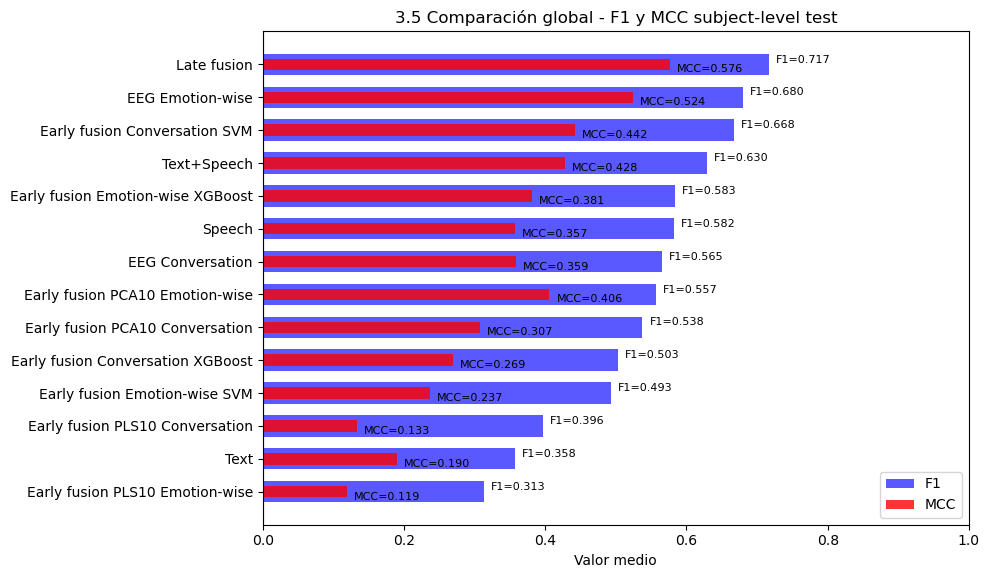

In [18]:
plot_f1_mcc_overlay(summary_35, title="3.5 Comparación global - F1 y MCC subject-level test")

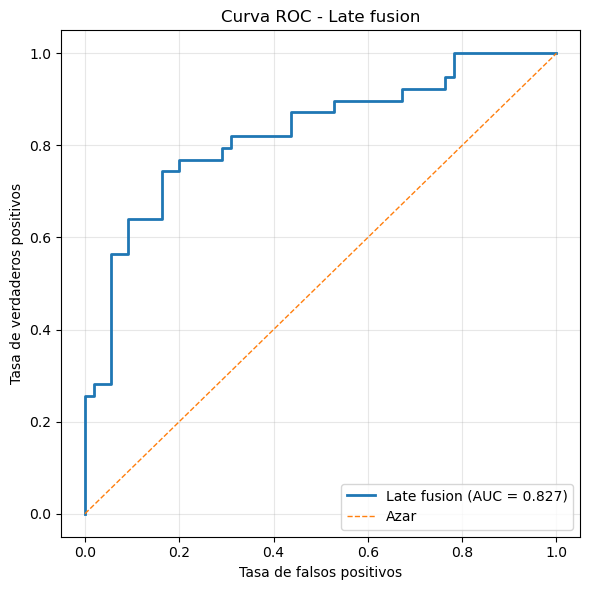

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Recuperar las predicciones del modelo Late Fusion
late_df = [df for df in predictions if df["model"].iloc[0] == "Late fusion"][0].copy()

# Etiqueta real y probabilidad predicha
y_true = late_df["label"].astype(int)
y_score = late_df["y_score"].astype(float)

# Cálculo de curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc_late = roc_auc_score(y_true, y_score)


# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Late fusion (AUC = {auc_late:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Azar")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Late fusion")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()